In [1]:
from lib import dbconnection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connessione al Database
# Utilizziamo la funzione dal tuo file dbconnection.py
engine = dbconnection.create_db_engine()

# 2. Estrazione dei Dati
# Prendiamo solo quello che serve. Filtriamo subito chi non ha una data.
query = """
    SELECT title, start_date
    FROM details
    WHERE start_date IS NOT NULL
"""

# Leggiamo direttamente in un DataFrame Pandas
df = pd.read_sql(query, engine)


In [2]:
# 3. Pulizia e Trasformazione
# Convertiamo start_date in datetime (gestisce vari formati)
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')

# Rimuoviamo righe dove la data non è stata convertita correttamente
df = df.dropna(subset=['start_date'])

# Estraiamo l'anno
df['year'] = df['start_date'].dt.year

# Calcoliamo la lunghezza del titolo (numero di caratteri)
df['title_length'] = df['title'].str.len()

# (Opzionale) Calcoliamo il numero di parole
df['word_count'] = df['title'].apply(lambda x: len(str(x).split()))



In [3]:
# 4. Analisi: Lunghezza media per anno
# Filtriamo eventuali anni futuri o troppo vecchi se ci sono errori (es. anno 2099)
df_filtered = df[(df['year'] >= 1960) & (df['year'] <= 2025)]

yearly_stats = df_filtered.groupby('year')[['title_length', 'word_count']].mean().reset_index()


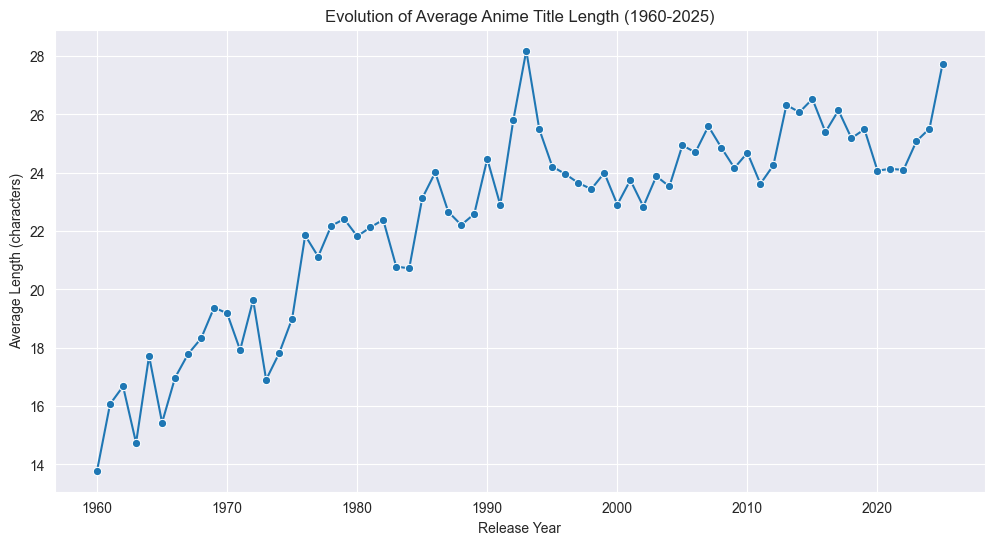

In [4]:
# 5. Visualizzazione
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_stats, x='year', y='title_length', marker='o')

plt.title('Evolution of Average Anime Title Length (1960-2025)')
plt.xlabel('Release Year')
plt.ylabel('Average Length (characters)')

plt.savefig('../../images/avgTitleLength.png', dpi=300, bbox_inches='tight')

plt.grid(True)
plt.show()